In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

nltk.download('stopwords')
from nltk.corpus import stopwords

# Load dataset
df = pd.read_csv('customer_support_text_classification.csv')

df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


Number of records: 1500

Target labels:
['neutral' 'positive' 'negative']

Sample text records:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object

Average text length: 72.75666666666666

Class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


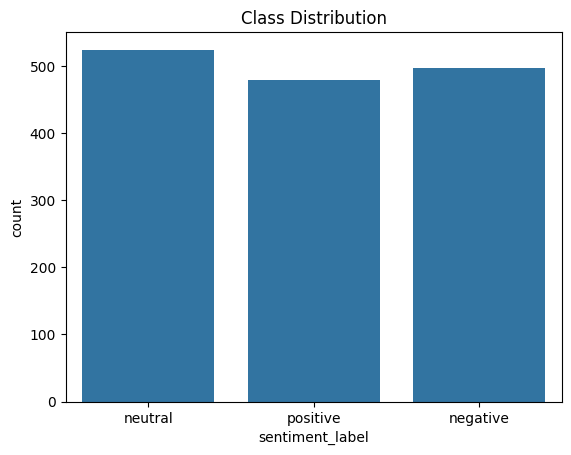

In [2]:
print("Number of records:", df.shape[0])

print("\nTarget labels:")
print(df['sentiment_label'].unique())

print("\nSample text records:")
print(df['customer_message'].head())

# Average text length
df['text_length'] = df['customer_message'].astype(str).apply(len)
print("\nAverage text length:", df['text_length'].mean())

# Class distribution
print("\nClass distribution:")
print(df['sentiment_label'].value_counts())

sns.countplot(x='sentiment_label', data=df)
plt.title("Class Distribution")
plt.show()

In [3]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['customer_message'].apply(clean_text)

print(df[['customer_message', 'clean_text']].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


In [4]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['sentiment_label']

print("Vectorized shape:", X.shape)

Vectorized shape: (1500, 146)


Text must be converted into vectors because machine learning models can only process numerical input, not raw text.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



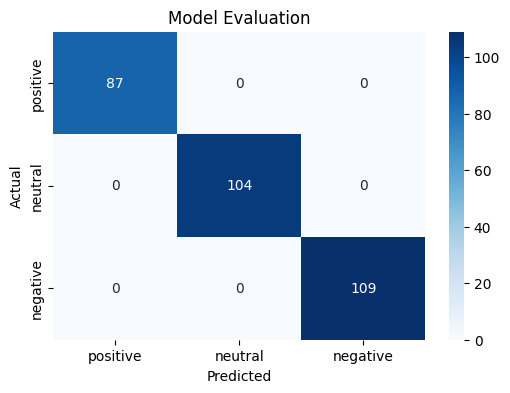

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['positive','neutral','negative'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive','neutral','negative'],
            yticklabels=['positive','neutral','negative'])
plt.title('Model Evaluation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('model_evaluation.png')
plt.show()

In [6]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_seq = pad_sequences(sequences, maxlen=50)

label_map = {'positive':0, 'neutral':1, 'negative':2}
y_seq = df['sentiment_label'].map(label_map)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=50),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Input sequence: tokenized customer messages
Embedding layer: converts words into dense vectors
Recurrent layer: LSTM captures sequence information
Output layer: softmax for 3 classes
Loss function: sparse_categorical_crossentropy
Evaluation metric: accuracy

RNNs struggle with long-term dependencies because earlier information can be forgotten over long sequences.

LSTMs solve this using memory cells and gates that preserve important information.

Attention helps by allowing the model to focus on important words in the sequence.

Transformers are important because they use self-attention and process text efficiently. Modern NLP systems like :contentReference[oaicite:0]{index=0} ChatGPT are based on transformer architecture.

In [8]:
sample = pd.DataFrame({
    'Text': X_test[:10].tolist(),
    'Actual': y_test.iloc[:10].tolist(),
    'Predicted': y_pred[:10]
})

with open('sample_predictions.txt', 'w') as f:
    for i in range(10):
        f.write(f"Actual: {sample['Actual'].iloc[i]}\n")
        f.write(f"Predicted: {sample['Predicted'].iloc[i]}\n")
        f.write("\n")

print("Saved")

Saved
